# 03 Classification - Metrics, Features, and Topics

This notebook evaluates the email urgency classifier after weak-label training. It focuses on accuracy, precision, recall, F1, threshold behavior, similarity features, meta features, feature importance, and BERTopic outputs.

The main input is `data/dataset.parquet`, generated by `scripts/run_train.py`. If `data/eval.parquet` exists, it is used for held-out evaluation views.

- Classification quality: where accuracy/F1/precision/recall are strong or weak.
- Threshold: whether the saved threshold is close to the F1-optimal region.
- Similarity features: whether urgent emails have higher positive-neighbor similarity or larger `gap_similarity`.
- Meta features: which structural or timing features differ most by urgency.
- Feature importance: whether the classifier depends mostly on embeddings, similarity, meta, or topic features.
- BERTopic: which topics dominate volume and which topics have high urgency rates.

In [31]:
from pathlib import Path
import sys

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 140)
plt.style.use("default")

PROJECT_ROOT = Path("..").resolve() if Path("../src").exists() else Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = Path("../data") if Path("../data").exists() else Path("data")
ARTIFACT_DIR = Path("../artifacts") if Path("../artifacts").exists() else Path("artifacts")

DATASET_PATH = DATA_DIR / "dataset.parquet"
EVAL_PATH = DATA_DIR / "eval.parquet"
MODEL_PATH = ARTIFACT_DIR / "classifier" / "logistic.joblib"

print("DATASET_PATH:", DATASET_PATH)
print("EVAL_PATH:", EVAL_PATH, "exists=", EVAL_PATH.exists())
print("MODEL_PATH:", MODEL_PATH, "exists=", MODEL_PATH.exists())

DATASET_PATH: ..\data\dataset.parquet
EVAL_PATH: ..\data\eval.parquet exists= True
MODEL_PATH: ..\artifacts\classifier\logistic.joblib exists= True


## Load Classification Outputs

`dataset.parquet` contains the training-time feature table with weak labels, selected threshold, out-of-fold probabilities, final predictions, similarity features, topic features, meta features, and embedding columns.

In [47]:
if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Missing {DATASET_PATH}. Run `make train` first.")

train_df = pd.read_parquet(DATASET_PATH, engine="pyarrow")
eval_df = pd.read_parquet(EVAL_PATH, engine="pyarrow") if EVAL_PATH.exists() else None

active_df = eval_df if eval_df is not None else train_df
active_name = "eval.parquet" if eval_df is not None else "dataset.parquet"

print("train_df:", train_df.shape)
print("eval_df:", None if eval_df is None else eval_df.shape)
print("active evaluation table:", active_name, active_df.shape)

required = ["label", "pred", "proba", "threshold"]
missing = [col for col in required if col not in active_df.columns]
if missing:
    raise ValueError(f"Missing required classification columns: {missing}")

train_df: (99438, 438)
eval_df: (30365, 436)
active evaluation table: eval.parquet (30365, 436)


## Classification Metrics

The primary metric view uses `label` vs `pred`. In this project, `label` is the manual gold label where available and otherwise the weak/silver label. A separate gold-only view is shown when `gold_labels` exists.

In [49]:
def metric_row(df, name, y_col="label", pred_col="pred"):
    mask = df[y_col].isin([0, 1]) & df[pred_col].isin([0, 1])
    y_true = df.loc[mask, y_col].astype(int)
    y_pred = df.loc[mask, pred_col].astype(int)
    return {
        "dataset": name,
        "n": int(mask.sum()),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "positive_rate_true": float(y_true.mean()) if len(y_true) else np.nan,
        "positive_rate_pred": float(y_pred.mean()) if len(y_pred) else np.nan,
    }

rows = [metric_row(active_df, active_name)]
if "gold_labels" in active_df.columns:
    gold_eval = active_df[active_df["gold_labels"].isin([0, 1])].copy()
    if not gold_eval.empty:
        rows.append(metric_row(gold_eval.rename(columns={"gold_labels": "gold_label"}), "gold-only", y_col="gold_label"))

metrics = pd.DataFrame(rows)
metrics.style.format({
    "accuracy": "{:.3f}",
    "precision": "{:.3f}",
    "recall": "{:.3f}",
    "f1": "{:.3f}",
    "positive_rate_true": "{:.3f}",
    "positive_rate_pred": "{:.3f}",
})

,dataset,n,accuracy,precision,recall,f1,positive_rate_true,positive_rate_pred
0,eval.parquet,30365,0.798,0.802,0.993,0.887,0.797,0.987
1,gold-only,26,0.269,0.269,1.000,0.424,0.269,1.000


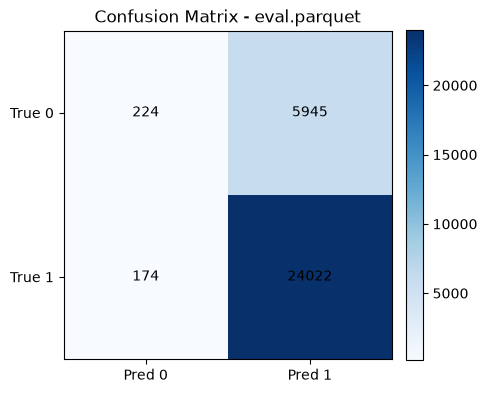

In [50]:
mask = active_df["label"].isin([0, 1]) & active_df["pred"].isin([0, 1])
y_true = active_df.loc[mask, "label"].astype(int)
y_pred = active_df.loc[mask, "pred"].astype(int)
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Pred 0", "Pred 1"])
ax.set_yticks([0, 1], labels=["True 0", "True 1"])
ax.set_title(f"Confusion Matrix - {active_name}")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

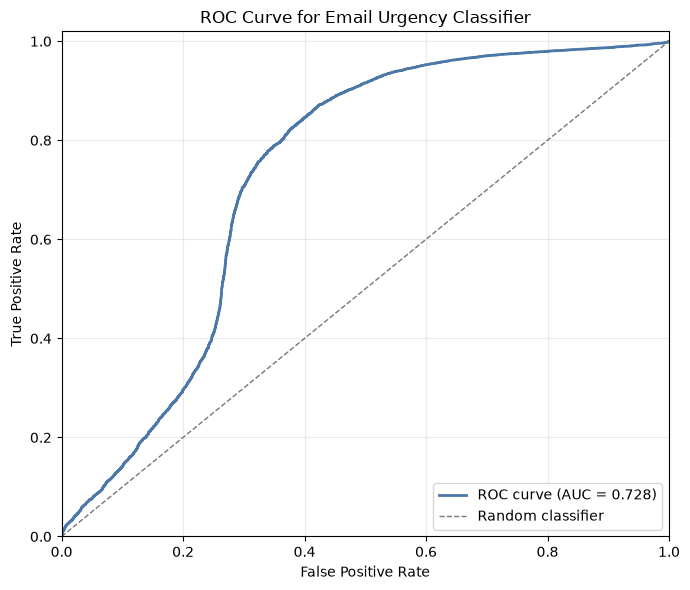

,metric,value
0,auc_roc,0.727844


,false_positive_rate,true_positive_rate,threshold
0,0.000000,0.000000,inf
1,0.000324,0.000331,1.0
2,0.000324,0.000413,1.0
3,0.000486,0.000413,1.0
4,0.000486,0.000455,1.0


In [66]:
from pathlib import Path

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd

EVAL_PATH = Path("../data/eval.parquet") if Path("../data/eval.parquet").exists() else Path("data/eval.parquet")

roc_source = pd.read_parquet(EVAL_PATH, engine="pyarrow")

roc_df = roc_source[["label", "proba"]].dropna().copy()
roc_df = roc_df[roc_df["label"].isin([0, 1])]
roc_df["label"] = roc_df["label"].astype(int)

if roc_df["label"].nunique() < 2:
    print("ROC/AUC cannot be computed because only one class is present.")
else:
    y_true = roc_df["label"].to_numpy()
    y_score = roc_df["proba"].to_numpy()

    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    auc_score = roc_auc_score(y_true, y_score)

    roc_points = pd.DataFrame({
        "false_positive_rate": fpr,
        "true_positive_rate": tpr,
        "threshold": thresholds,
    })

    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(fpr, tpr, color="#4c78a8", linewidth=2, label=f"ROC curve (AUC = {auc_score:.3f})")
    ax.plot([0, 1], [0, 1], color="#777777", linestyle="--", linewidth=1, label="Random classifier")

    ax.set_title("ROC Curve for Email Urgency Classifier")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(loc="lower right")
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    display(pd.DataFrame({"metric": ["auc_roc"], "value": [auc_score]}))
    display(roc_points.head())

## Threshold Behavior

The classifier saves a tuned threshold. This chart shows how precision, recall, and F1 move across possible probability cutoffs.

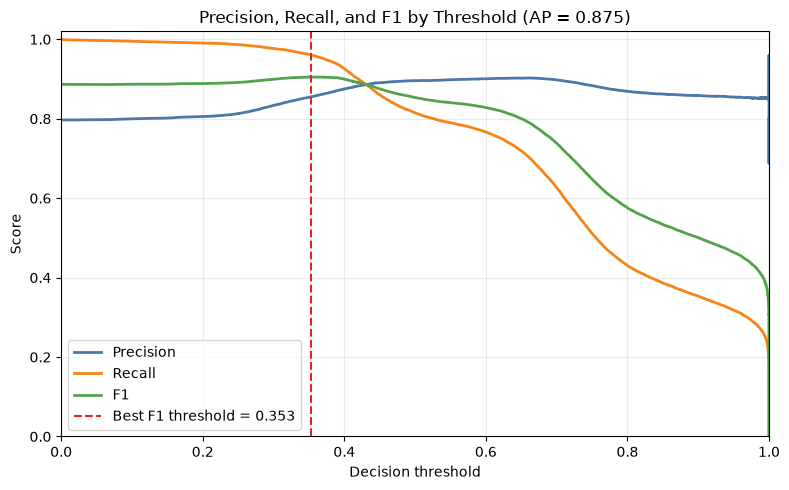

,metric,value
0,best_threshold,0.352939
1,precision,0.855193
2,recall,0.960944
3,f1,0.904990
4,average_precision,0.874796


,threshold,precision,recall,f1
0,0.000000e+00,0.796838,1.000000,0.886934
1,1.660938e-211,0.796865,1.000000,0.886950
2,8.969747e-184,0.796858,0.999959,0.886930
3,3.336433e-11,0.796884,0.999959,0.886946
4,2.644867e-08,0.796878,0.999917,0.886926


In [70]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

pr_df = roc_source[["label", "proba"]].dropna().copy()
pr_df = pr_df[pr_df["label"].isin([0, 1])]
pr_df["label"] = pr_df["label"].astype(int)

if pr_df["label"].nunique() < 2:
    print("Precision/recall/F1 curves cannot be computed because only one class is present.")
else:
    y_true = pr_df["label"].to_numpy()
    y_score = pr_df["proba"].to_numpy()

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    average_precision = average_precision_score(y_true, y_score)

    # precision and recall have one extra point compared with thresholds
    curve_df = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision[:-1],
        "recall": recall[:-1],
    })

    curve_df["f1"] = np.where(
        (curve_df["precision"] + curve_df["recall"]) > 0,
        2 * curve_df["precision"] * curve_df["recall"] / (curve_df["precision"] + curve_df["recall"]),
        0.0,
    )

    best_idx = curve_df["f1"].idxmax()
    best_row = curve_df.loc[best_idx]

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(curve_df["threshold"], curve_df["precision"], label="Precision", color="#4c78a8", linewidth=2)
    ax.plot(curve_df["threshold"], curve_df["recall"], label="Recall", color="#f58518", linewidth=2)
    ax.plot(curve_df["threshold"], curve_df["f1"], label="F1", color="#54a24b", linewidth=2)

    ax.axvline(
        best_row["threshold"],
        color="#d62728",
        linestyle="--",
        linewidth=1.5,
        label=f"Best F1 threshold = {best_row['threshold']:.3f}",
    )

    ax.set_title(f"Precision, Recall, and F1 by Threshold (AP = {average_precision:.3f})")
    ax.set_xlabel("Decision threshold")
    ax.set_ylabel("Score")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.legend(loc="best")
    ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    display(pd.DataFrame({
        "metric": ["best_threshold", "precision", "recall", "f1", "average_precision"],
        "value": [
            best_row["threshold"],
            best_row["precision"],
            best_row["recall"],
            best_row["f1"],
            average_precision,
        ],
    }))

    display(curve_df.head())

## Similarity Features

Similarity features summarize nearest-neighbor structure in embedding space. They help identify whether an email looks close to previously urgent or non-urgent examples.

In [54]:
similarity_cols = [
    "max_similarity",
    "mean_similarity",
    "std_similarity",
    "top_k_mean_similarity",
    "top_k_std_similarity",
    "top_k_pos_similarity",
    "top_k_neg_similarity",
    "gap_similarity",
]
similarity_cols = [col for col in similarity_cols if col in active_df.columns]

summary = active_df.groupby("label")[similarity_cols].agg(["mean", "median", "std"]).round(3)
summary

max_similarity               mean_similarity                \
                mean median    std            mean median    std   
label                                                              
0              0.810  0.938  0.213           0.733  0.682  0.239   
1              0.745  0.713  0.166           0.636  0.608  0.140   

      std_similarity               top_k_mean_similarity                \
                mean median    std                  mean median    std   
label                                                                    
0              0.034  0.018  0.049                 0.733  0.682  0.239   
1              0.050  0.033  0.043                 0.636  0.608  0.140   

      top_k_std_similarity               top_k_pos_similarity                \
                      mean median    std                 mean median    std   
label                                                                         
0                    0.034  0.018  0.049                0.650  0.590  0.303   
1                    0.050  0.033  0.043                0.637  0.609  0.141   

      top_k_neg_similarity               gap_similarity                
                      mean median    std           mean median    std  
label                                                                  
0                    0.703  0.741  0.309         -0.053  0.000  0.312  
1                    0.204  0.000  0.292          0.433  0.557  0.328

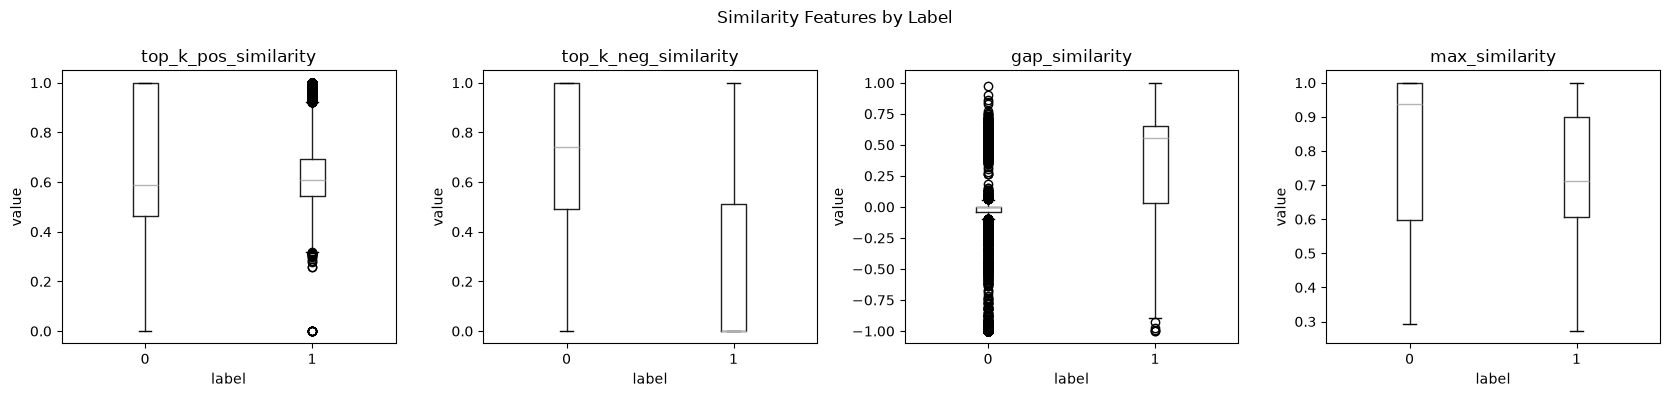

In [55]:
plot_cols = [col for col in ["top_k_pos_similarity", "top_k_neg_similarity", "gap_similarity", "max_similarity"] if col in active_df.columns]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(4.2 * len(plot_cols), 4), sharey=False)
if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    active_df.boxplot(column=col, by="label", ax=ax, grid=False)
    ax.set_title(col)
    ax.set_xlabel("label")
    ax.set_ylabel("value")

plt.suptitle("Similarity Features by Label")
plt.tight_layout()
plt.show()

## Meta Features

Meta features capture email structure and timing, such as send hour, recipient counts, text length, and internal/external routing.

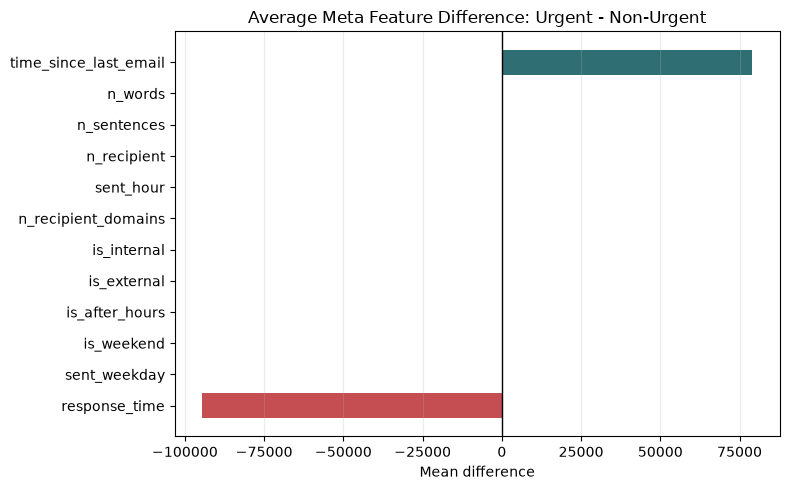

In [57]:
if "diff_urgent_minus_nonurgent" in meta_summary.columns:
    diff = meta_summary["diff_urgent_minus_nonurgent"].dropna().sort_values()

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ["#c44e52" if value < 0 else "#2f6f73" for value in diff]
    ax.barh(diff.index, diff.values, color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title("Average Meta Feature Difference: Urgent - Non-Urgent")
    ax.set_xlabel("Mean difference")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

## Feature Importance

For logistic regression, feature importance is based on coefficient magnitude. Positive coefficients push predictions toward urgent; negative coefficients push predictions toward non-urgent.

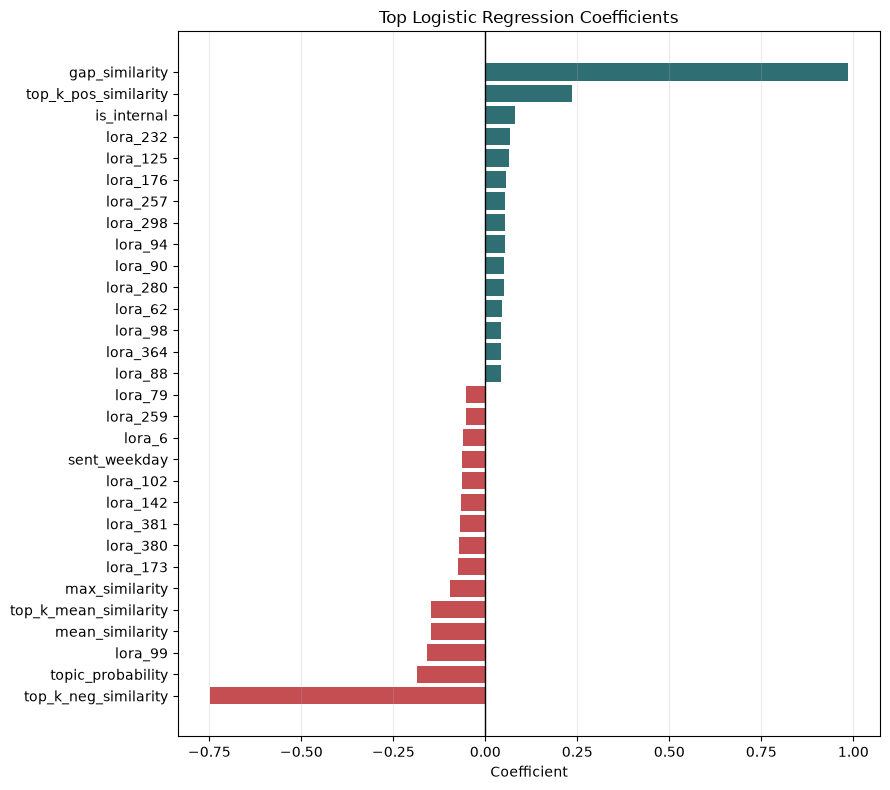

In [59]:
if not importance.empty:
    top = pd.concat([
        importance.sort_values("coef", ascending=True).head(15),
        importance.sort_values("coef", ascending=False).head(15),
    ]).sort_values("coef")

    fig, ax = plt.subplots(figsize=(9, 8))
    colors = np.where(top["coef"] >= 0, "#2f6f73", "#c44e52")
    ax.barh(top["feature"], top["coef"], color=colors)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title("Top Logistic Regression Coefficients")
    ax.set_xlabel("Coefficient")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

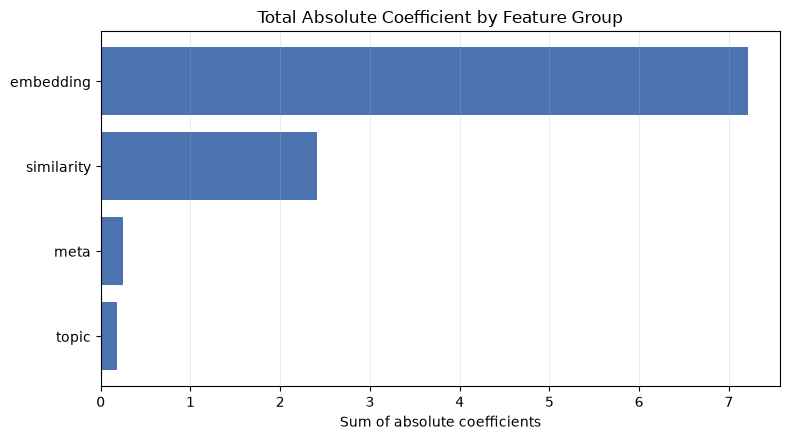

In [60]:
if not importance.empty:
    group_importance = (
        importance.groupby("group")
        .agg(n_features=("feature", "count"), mean_abs_coef=("abs_coef", "mean"), total_abs_coef=("abs_coef", "sum"))
        .sort_values("total_abs_coef", ascending=True)
    )

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh(group_importance.index, group_importance["total_abs_coef"], color="#4c72b0")
    ax.set_title("Total Absolute Coefficient by Feature Group")
    ax.set_xlabel("Sum of absolute coefficients")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

    group_importance.sort_values("total_abs_coef", ascending=False).round(4)

## BERTopic Results

Topic features come from BERTopic and are stored as `topic` and `topic_probability`.
`topic = -1` means the document was assigned to the BERTopic noise cluster and not a real cluster.
The views below show topic volume, urgency rate by topic, topic confidence, and human-readable topic labels when the BERTopic model is available.


In [ ]:
if {"topic", "topic_probability"}.issubset(active_df.columns):
    topic_info = pd.DataFrame()
    try:
        from configs.train_config import get_berttopic_config
        from src.emailurgency.models.berttopic import BERTTopicModel

        topic_config = get_berttopic_config()
        berttopic = BERTTopicModel.load(topic_config.model_path, config=topic_config)
        topic_info = berttopic.berttopic_model.get_topic_info()
        topic_map = dict(zip(topic_info["Topic"], topic_info["Name"]))
        active_df["topic_name"] = active_df["topic"].map(topic_map).fillna("noise")
    except Exception as exc:
        print("Could not load BERTopic model for topic labels:", exc)
        active_df["topic_name"] = active_df["topic"].astype(str)

    if not topic_info.empty:
        print("BERTopic topic labels:")
        display(topic_info[["Topic", "Name"]].head(40))

    topic_summary = (
        active_df.groupby(["topic", "topic_name"])
        .agg(
            n=("message_id", "count"),
            urgent_rate=("label", "mean"),
            pred_urgent_rate=("pred", "mean"),
            mean_probability=("proba", "mean"),
            mean_topic_probability=("topic_probability", "mean"),
        )
        .sort_values("n", ascending=False)
    )
else:
    topic_summary = pd.DataFrame()

topic_summary.head(20).round(3)


Could not load BERTopic model for topic labels: Make sure to either pass a valid directory or HF model.


,,n,urgent_rate,pred_urgent_rate,mean_probability,mean_topic_probability
topic,topic_name,,,,,
-1,-1,16055,0.853,0.981,0.588,0.000
187,187,2141,0.140,0.977,0.331,0.001
8502,8502,28,0.964,1.000,1.000,0.993
227,227,20,1.000,1.000,0.713,0.680
1186,1186,17,1.000,1.000,0.859,0.653
392,392,16,0.938,1.000,0.716,0.747
13712,13712,15,1.000,1.000,1.000,0.908
20871,20871,15,0.933,1.000,1.000,0.611
34,34,15,1.000,1.000,0.730,0.829


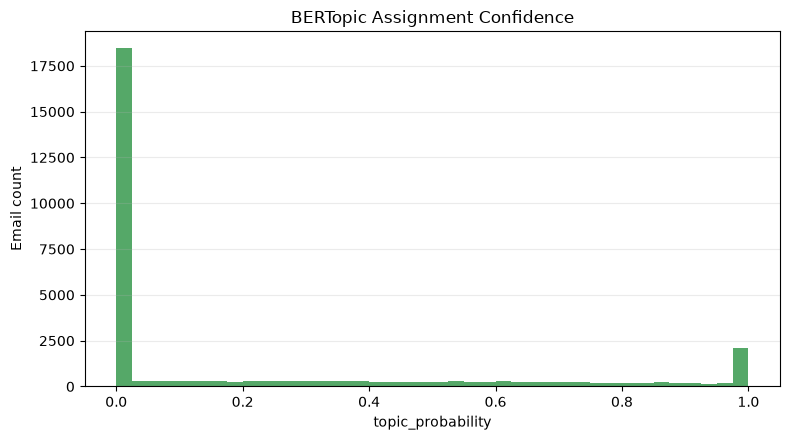

In [63]:
if "topic_probability" in active_df.columns:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    active_df["topic_probability"].dropna().plot(kind="hist", bins=40, ax=ax, color="#55a868")
    ax.set_title("BERTopic Assignment Confidence")
    ax.set_xlabel("topic_probability")
    ax.set_ylabel("Email count")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

## High-Confidence Examples by Topic

Use this table to inspect representative emails for large or high-urgency topics.

In [17]:
example_cols = [col for col in ["topic", "topic_probability", "label", "pred", "proba", "subject", "body"] if col in active_df.columns]
examples = (
    active_df[example_cols]
    .sort_values(["topic_probability", "proba"], ascending=False)
    .groupby("topic", as_index=False)
    .head(3)
    .sort_values(["topic", "topic_probability"], ascending=[True, False])
)
examples.head(30)

,topic,topic_probability,label,pred,proba,subject,body
23530,-1,0.000000,1,1,1.000000,,"dan, this was the reaction that i just got from smud. i am assuming that we didn't incorporate any of their language, which is fine. it ..."
23535,-1,0.000000,1,1,1.000000,,"he should be good! stacey from: melba lozano 03/13/2001 02:55 pm to: stacey w white/hou/, dawn c kenne/hou/, tara sweitzer/hou/ cc: joe ..."
8475,-1,0.000000,1,1,1.000000,texas ecomm ten awards,"sounds like a good idea to me ----original message----- >from: eric thode/corp/enron >to: mark frevert/na/,greg whalley/hou/,mark palmer..."
11442,0,0.943506,1,1,0.615225,your approval is overdue: access request for william.freije@enron.com,this request has been pending your approval for 29 days. please click to review and act upon this request. request id : 000000000059231 ...
7630,3,0.353152,0,1,0.322347,start date: 12/24/01; hourahead hour: 13;,start date: 12/24/01; hourahead hour: 13; no ancillary schedules awarded. no variances detected. log messages: parsing file -->> o:\port...
20361,5,1.000000,1,1,0.721733,warning: your mailbox is approaching the size limit,this warning is sent automatically to inform you that your mailbox is approaching the maximum size limit. your mailbox size is currently...
30197,5,1.000000,1,1,0.657388,warning: your mailbox is approaching the size limit,this warning is sent automatically to inform you that your mailbox is approaching the maximum size limit. your mailbox size is currently...
8318,5,0.954681,1,1,0.675319,warning: your mailbox is approaching the size limit,this warning is sent automatically to inform you that your mailbox is approaching the maximum size limit. your mailbox size is currently...
3343,14,1.000000,1,1,0.629173,upcoming wellness activities,"cpr and first aid certification cpr and first aid certification is being offered on thursday, november 15, 2001, from 1:30 p.m. - 5:30 p..."
5760,14,1.000000,1,1,0.629173,upcoming wellness activities,"cpr and first aid certification cpr and first aid certification is being offered on thursday, november 15, 2001, from 1:30 p.m. - 5:30 p..."
